# Preferred Stocks 🎩
### A "bond" that lost *more* than the stock market in 2008 — is preferred-stock safety real?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Bond-like safety?: Busted](https://img.shields.io/badge/Bond--like_safety%3F-Busted-8b949e?style=flat-square)

Preferred shares (and the ETF that holds a basket of them, **PFF**) are sold as a third asset class: *bond-like safety with an equity-like yield.* A fixed ~6% coupon, senior to common stock — high income, low risk, the pitch goes. We line PFF up next to a stock fund and a bond fund and ask the only question that matters: when the market crashes, does PFF act like the bond it's sold as, or like the stock it really is?

> 📓 **This is the plain-language layer.** The betas, the HAC *t* and the bootstrap are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Educational, reproducible research — every chart below is generated by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (preferred_stocks/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from preferred_stocks import data, strategy

AS_OF = "2026-05-31"
# Try the REAL total-return tapes; fall back to the offline synthetic control if the
# network is blocked. Every cell prints which TAPE it is showing.
try:
    prices = data.load_real(("PFF", "SPY", "IEF")).loc[:AS_OF]
    cols = {"PFF": "PFF", "SPY": "SPY", "BND": "IEF"}   # bond proxy label
    TAPE = "REAL"
except Exception as e:
    print("network/cache miss -> SYNTHETIC control tape:", type(e).__name__)
    prices, _truth = data.synthetic_three_asset(pref_beta=0.90, seed=338)
    cols = {"PFF": "PFF", "SPY": "SPY", "BND": "BND"}
    TAPE = "SYNTHETIC"

PFF, SPY, BND = cols["PFF"], cols["SPY"], cols["BND"]
rets = strategy.to_returns(prices)
BANNER = ("REAL total-return tape (PFF/SPY/IEF, 2007-2026)" if TAPE == "REAL"
          else "SYNTHETIC control tape (pref_beta=0.90) -- NOT market data")
print(f"[{TAPE}] {BANNER}")
print(f"panel: {len(prices):,} rows  {prices.index[0].date()} -> {prices.index[-1].date()}  fingerprint={data.fingerprint(prices)}")
for c in (PFF, SPY, BND):
    s = strategy.stats(rets[c])
    print(f"  {c}: CAGR {s['cagr']*100:6.2f}%  vol {s['vol']*100:5.1f}%  Sharpe {s['sharpe']:.3f}  maxDD {s['max_dd']*100:6.1f}%")


[REAL] REAL total-return tape (PFF/SPY/IEF, 2007-2026)
panel: 4,822 rows  2007-03-30 -> 2026-05-29  fingerprint=225bc4dab397
  PFF: CAGR   3.88%  vol  18.7%  Sharpe 0.298  maxDD  -65.5%
  SPY: CAGR  11.16%  vol  19.7%  Sharpe 0.635  maxDD  -55.2%
  IEF: CAGR   3.26%  vol   7.0%  Sharpe 0.495  maxDD  -23.9%


## The answer first 🎯

| Question | Answer |
|---|---|
| Does the fat coupon pay off? | Barely — **3.88%/yr**, about the same as a plain Treasury fund (**3.26%/yr**). |
| Is the ride bond-like? | **No** — vol **18.7%** (a stock's), and its worst fall was **-65.5%**, *deeper than the S&P 500's* (**-55.2%**). |
| Does it move like a bond in a crash? | **No** — PFF fell in **7 of 7** equity crashes; in 2008 it lost **-63.7%** while bonds *gained* **+20.2%**. |

> *Headline numbers are the **real** 2007–2026 tape (`docs/results.md`, fingerprint `225bc4dab397`). If the executed cells below show a SYNTHETIC banner, the live data was blocked and the harness fell back to the offline control — the prose numbers still refer to the real run.*

## 1 · The claim

*"Preferred shares are a third asset class — bond-like safety with an equity-like yield. You collect a fixed, fat coupon (~6%), you sit **senior to common stock**, so you get high income with much less risk than equities."* It's how brokerages file preferreds: under **fixed income**, in the *safe* bucket, next to the bonds.

## 2 · So what?

If the pitch is true, PFF is the perfect retirement income sleeve — more yield than bonds, less drama than stocks. If it's false, millions of income investors are holding **equity-grade crash risk** in the part of the portfolio they believe is safe — and they find out at the worst possible moment. The label decides where you put it.

## 3 · How would we even know?

We compare PFF (total return) to a **stock** fund (SPY) and a **bond** fund (IEF, 7-10y Treasuries) from 2007 — so PFF's very first test was the 2008 crisis. We look at the return, the volatility, and the worst drawdown. Then the decisive test: every time stocks fell more than 10%, **did PFF rise (like a bond) or fall (like a stock)?**

## 4 · The teardown — let's actually look

First, the three equity curves and their drawdowns. Watch what the 'safe' line does in 2008.

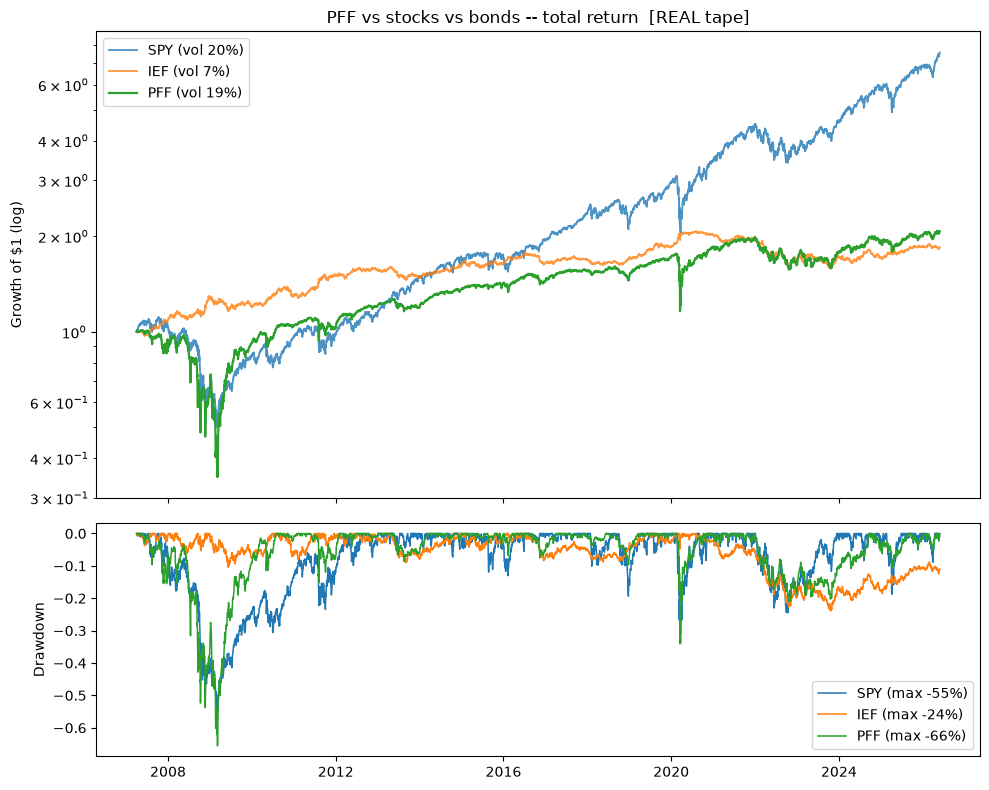

In [2]:
stats = {c: strategy.stats(rets[c]) for c in (PFF, SPY, BND)}
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, height_ratios=[2, 1])
for c, style in [(SPY, dict(lw=1.3, alpha=.8)), (BND, dict(lw=1.3, alpha=.8)), (PFF, dict(lw=1.6))]:
    ax1.plot(stats[c]['equity'], label=f"{c} (vol {stats[c]['vol']*100:.0f}%)", **style)
ax1.set_yscale('log'); ax1.set_ylabel('Growth of $1 (log)'); ax1.legend()
ax1.set_title(f'PFF vs stocks vs bonds -- total return  [{TAPE} tape]')
for c in (SPY, BND, PFF):
    eq = stats[c]['equity']; dd = eq/eq.cummax()-1
    ax2.plot(dd, label=f"{c} (max {dd.min()*100:.0f}%)", lw=1.1)
ax2.set_ylabel('Drawdown'); ax2.legend(); ax2.set_xlabel('')
plt.tight_layout(); plt.show()

The PFF drawdown line plunges with — or *below* — the stock line in every selloff. A real bond fund (the IEF line) barely moves. That's the whole story in one chart: PFF's **risk** is shaped like a stock's, not a bond's.

Now the decisive test. Every time stocks fell more than 10%, here's what PFF and bonds did over the *same* window:

In [3]:
eps = strategy.equity_drawdowns(rets[[SPY, PFF, BND]], SPY, thresh=-0.10)
rows = [{'peak':e['peak'].date(),'trough':e['trough'].date(),
         f'{SPY} %':e['stock_loss']*100, f'{PFF} %':e['others'][PFF]*100, f'{BND} %':e['others'][BND]*100} for e in eps]
dd = pd.DataFrame(rows)
pff_fell = (dd[f'{PFF} %']<0).sum(); bnd_rose = (dd[f'{BND} %']>0).sum()
print(f'[{TAPE}] PFF fell in {pff_fell}/{len(dd)} equity crashes; bonds rose in {bnd_rose}/{len(dd)}')
dd.round(1)

[REAL] PFF fell in 7/7 equity crashes; bonds rose in 5/7


,peak,trough,SPY %,PFF %,IEF %
0,2007-10-09,2009-03-09,-55.200,-63.700,20.200
1,2015-07-20,2016-02-11,-13.000,-5.000,7.400
2,2018-01-26,2018-02-08,-10.100,-2.400,-1.200
3,2018-09-20,2018-12-24,-19.300,-8.100,3.400
4,2020-02-19,2020-03-23,-33.700,-30.800,6.400
5,2022-01-03,2022-10-12,-24.500,-18.500,-15.400
6,2025-02-19,2025-04-08,-18.800,-7.600,2.700


On the real tape PFF fell in **7 of 7** equity crashes; bonds rose in **5**. The headline case is the GFC: PFF lost **-63.7%** — *more than the S&P 500's -55.2%* — while Treasuries **gained +20.2%**. The 'cushion' was the opposite of a cushion.

## 5 · The verdict

- **Signal → Real.** PFF moves with stocks, not bonds (beta to stocks +0.55, to bonds -0.206), and it fell in 7/7 crashes — the equity-like risk is real, not a fluke.
- **Tradability → Mirage.** You earn a bond's return (3.88%/yr) for an equity's risk (vol 18.7%, worst fall -65.5%). As a *safe* income sleeve, it's a mirage.
- **Bond-like safety? → Busted.** Senior-to-common and a fat coupon don't make a bond. In a crash, PFF is a stock.

## 6 · Could you actually trade it?

You *can* buy PFF in one click — it's liquid in normal times. The problem isn't friction, it's **what you're holding**: a perpetual, callable, deeply junior security, heavily concentrated in **banks and insurers** — the exact sector that detonates in a crisis. You're paid a coupon for that risk; you are not handed safety. If you want *income with safety*, a Treasury or IG-bond fund delivers the safety part for real.

## 7 · Going further 🚪

- Does an **active** preferred fund or a non-financials-heavy index (PFFD, PFXF) escape the 2008 result? (Spoiler: the sector concentration is structural.)
- Split PFF's return into **coupon vs price**: how much of the 3.9%/yr is just the coupon being clawed back by capital losses in crashes?
- Compare to other 'is it what the brochure says?' teardowns: gold ([Study 69](../../69-safe-haven/)), REITs ([Study 207](../../207-reits-diversifier/)).